In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy import stats

In [ ]:
import pandas as pd
df = pd.read_csv('adult_dataset.csv')

In [ ]:
print(df.head())
print(df.info())
print(df.describe())

In [ ]:
import numpy as np
# Handle missing values: '?' is missing, replace with NaN
df.replace('?', np.nan, inplace=True)
df.replace('', np.nan, inplace=True)

In [ ]:
from sklearn.impute import SimpleImputer
# Impute missing values
num_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
num_imputer = SimpleImputer(strategy='median')
df[num_features] = num_imputer.fit_transform(df[num_features])

In [ ]:
cat_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
cat_imputer = SimpleImputer(strategy='most_frequent')  # Mode for categorical
df[cat_features] = cat_imputer.fit_transform(df[cat_features])

In [ ]:
from sklearn.preprocessing import OneHotEncoder
# Encode categorical variables: Use OneHotEncoder for nominal categories
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = ohe.fit_transform(df[cat_features])
cat_encoded_df = pd.DataFrame(cat_encoded, columns=ohe.get_feature_names_out(cat_features))

In [ ]:
df = df.drop(cat_features, axis=1)
df = pd.concat([df, cat_encoded_df], axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['income_encoded'] = le.fit_transform(df['income'])  # <=50K:0, >50K:1
income = df['income']  # Keep original for reference
df_clustering = df.drop(['income', 'income_encoded'], axis=1)

In [ ]:
# Detect and treat outliers: Using IQR method for numerical features
for feature in num_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Cap outliers
    df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
    df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])

In [ ]:
from sklearn.preprocessing import StandardScaler
# Normalize/scale numerical features
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

In [ ]:
#Update df_clustering after scaling
df_clustering = df.drop(['income', 'income_encoded'], axis=1)

### 2. Exploratory **Analysis**

> Add blockquote



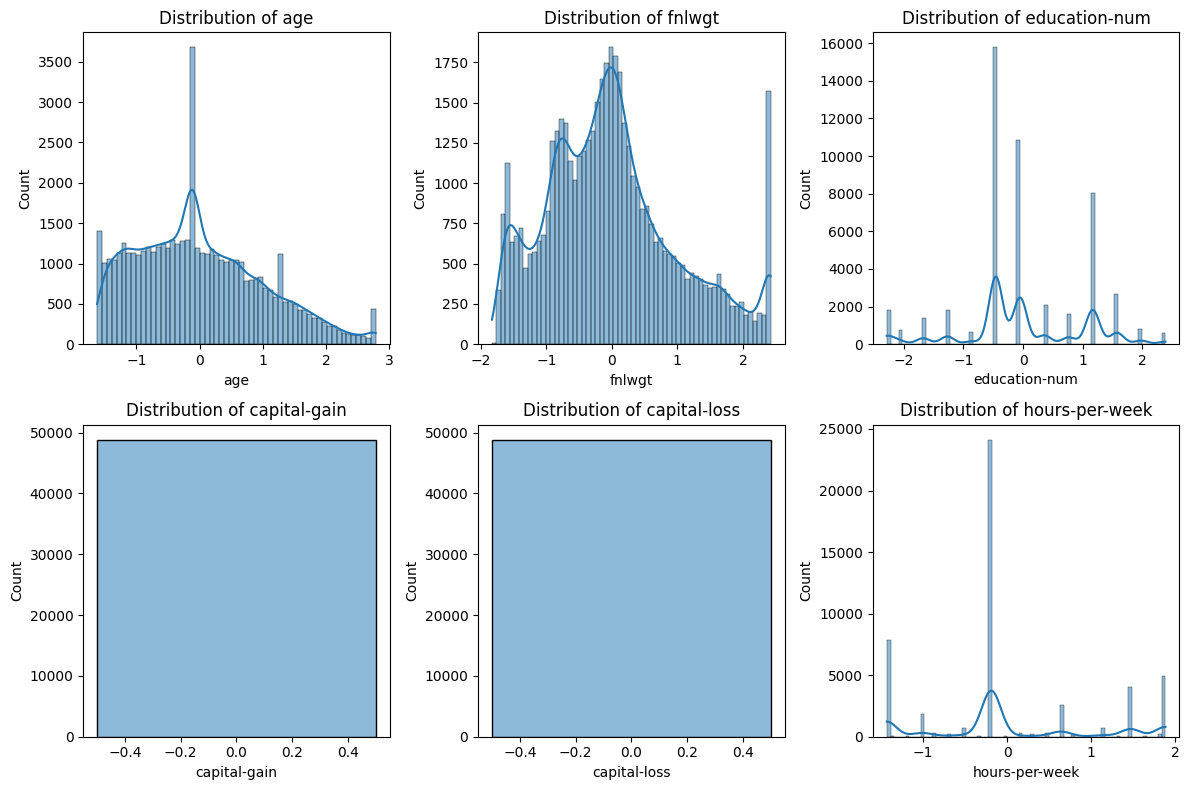

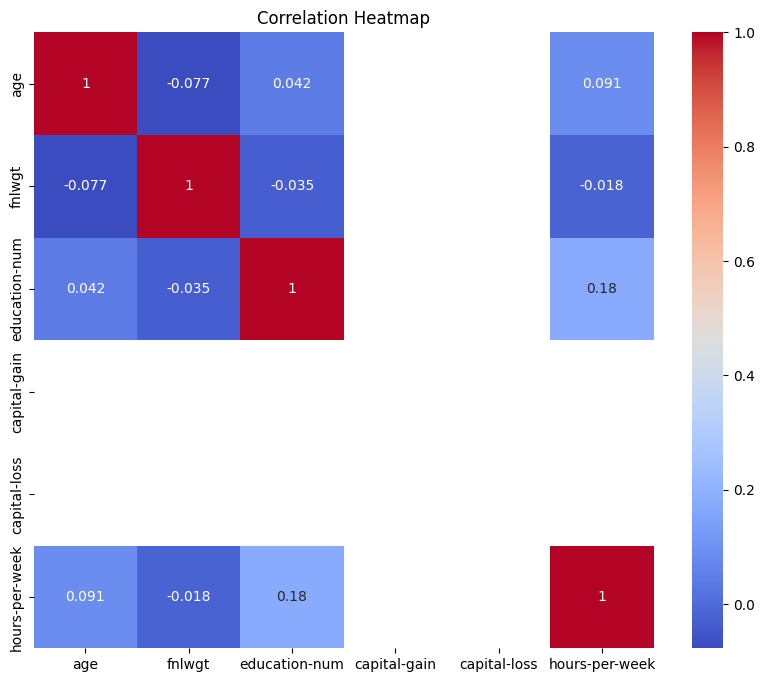

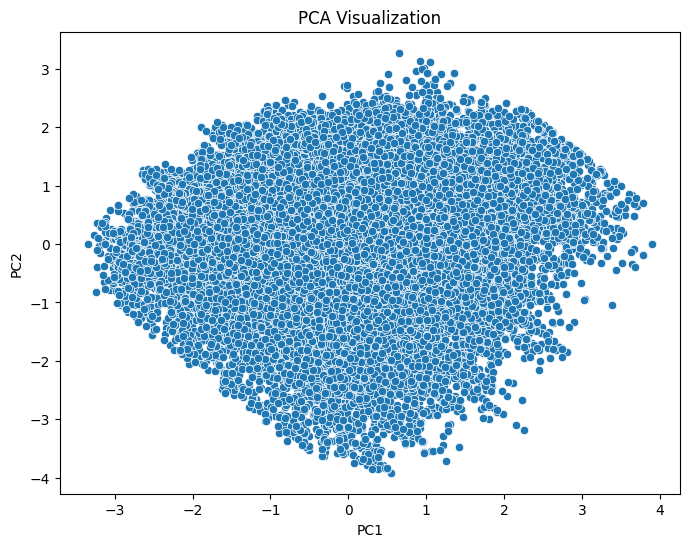

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
# Visualize feature distributions (example for numerical)
plt.figure(figsize=(12, 8))
for i, feature in enumerate(num_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Analyze correlations (numerical only for simplicity)
corr = df[num_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Dimensionality reduction for visualization: PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_clustering)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df)
plt.title('PCA Visualization')
plt.show()

# t-SNE (perplexity=30 as example)
tsne = TSNE(n_components=2, random_state=42)
tsne_data = tsne.fit_transform(df_clustering)
tsne_df = pd.DataFrame(tsne_data, columns=['Dim1', 'Dim2'])
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Dim1', y='Dim2', data=tsne_df)
plt.title('t-SNE Visualization')
plt.show()

# 3. Clustering

# KMeans: Elbow method and silhouette score to choose k
inertia = []
sil_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_clustering)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(df_clustering, kmeans.labels_))

# Plot elbow
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot silhouette
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

In [ ]:
# Choose optimal k (assuming from plots, let's say k=3 for example; adjust based on plot)
optimal_k = 3  # Replace with actual optimal from elbow/silhouette
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(df_clustering)

In [ ]:
# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=optimal_k)
df['agg_cluster'] = agg.fit_predict(df_clustering)

In [ ]:
# Visualize clusters (using PCA)
pca_df['kmeans_cluster'] = df['kmeans_cluster']
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='kmeans_cluster', data=pca_df, palette='viridis')
plt.title('KMeans Clusters (PCA)')
plt.show()

pca_df['agg_cluster'] = df['agg_cluster']
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='agg_cluster', data=pca_df, palette='viridis')
plt.title('Agglomerative Clusters (PCA)')
plt.show()

In [ ]:
# 4. Interpretation & Profiling

# For each cluster (using KMeans as primary)
for cluster in range(optimal_k):
    cluster_data = df[df['kmeans_cluster'] == cluster]
    print(f"\nCluster {cluster} Profile:")
    print(cluster_data[num_features].mean())  # Numerical means
    # Categorical modes (original cats before encoding)
    for cat in cat_features:
        print(f"{cat} mode: {cluster_data[cat].mode()[0] if not cluster_data[cat].empty else 'N/A'}")

In [ ]:

# Compare with income
pd.crosstab(df['kmeans_cluster'], income).plot(kind='bar', stacked=True)
plt.title('Cluster vs Income')
plt.show()

# Insights and Suggestions
# Example based on hypothetical clusters:
# Cluster 0: Young, low education, low hours -> Upskilling programs
# Cluster 1: Middle-aged, high capital, professionals -> Tax reform
# Cluster 2: Low income groups -> Financial aid

print("\nPolicy Suggestions:")
print("- Cluster 0: Target with upskilling and employment programs.")
print("- Cluster 1: Consider tax reforms for high earners.")
print("- Cluster 2: Financial inclusion efforts for low socioeconomic groups.")